# GameTheory-04-NashEquilibrium

**Navigation** : [<< 3-Topology2x2](GameTheory-03-Topology2x2.ipynb) | [Index](README.md) | [5-ZeroSum-Minimax >>](GameTheory-05-ZeroSum-Minimax.ipynb)

**Side tracks** : [4b-Lean-NashExistence](GameTheory-04b-Lean-NashExistence.ipynb) | [4c-NashExistence-Python](GameTheory-04c-NashExistence-Python.ipynb)

## Equilibres de Nash : Purs et Mixtes

Ce notebook explore en profondeur les **equilibres de Nash**, concept central de la théorie des jeux.

### Objectifs d'apprentissage

1. Définir formellement l'equilibre de Nash
2. Calculer les equilibres purs par best response
3. Introduire les stratégies mixtes
4. Calculer les equilibres mixtes
5. Utiliser les algorithmes : Support Enumeration, Lemke-Howson
6. Analyser parametriquement les equilibres

### Prerequis

- Notebooks 1-3 : Fondations, jeux en forme normale, topologie des jeux 2x2
- Notion de best response et de stratégie dominante
- Bases de l'algebre lineaire (produit matriciel)

### Duree estimee : 60 minutes

### Theoreme de Nash (1950)
> Tout jeu fini a au moins un equilibre de Nash (potentiellement en stratégies mixtes).

**Source primaire.** L'existence de l'equilibre de Nash est demontree par John F. Nash dans *Equilibrium Points in N-Person Games* (Proceedings of the National Academy of Sciences 36(1):48-49, 1950 ; DOI 10.1073/pnas.36.1.48), puis developpee en pleine generalite dans *Non-Cooperative Games* (Annals of Mathematics 54(2):286-295, 1951). L'existence repose sur le theoreme du point fixe de Brouwer (point fixe de la meilleure reponse), detaille dans le side track Lean [4b-NashExistence](GameTheory-04b-Lean-NashExistence.ipynb).

In [1]:
# Imports
import numpy as np
import nashpy as nash
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')
print("Imports OK : numpy, scipy, itertools")


Imports OK : numpy, scipy, itertools


## 1. Definition formelle

### Equilibre de Nash

Un profil de stratégies $\sigma^* = (\sigma_1^*, \sigma_2^*, ..., \sigma_n^*)$ est un **equilibre de Nash** si :

$$u_i(\sigma_i^*, \sigma_{-i}^*) \geq u_i(\sigma_i, \sigma_{-i}^*) \quad \forall i \in N, \forall \sigma_i \in \Sigma_i$$

Autrement dit, **aucun joueur n'a intérêt a devier unilateralement**.

### Types d'equilibres

| Type | Description |
|------|-------------|
| **Nash pur** | Chaque joueur joue une action déterministe |
| **Nash mixte** | Au moins un joueur randomise entre plusieurs actions |

In [2]:
class Game2x2:
    """
    Jeu 2x2 avec calcul d'equilibres.
    """
    
    def __init__(self, A: np.ndarray, B: np.ndarray, 
                 row_labels: List[str] = None,
                 col_labels: List[str] = None,
                 name: str = "Game"):
        self.A = np.array(A, dtype=float)
        self.B = np.array(B, dtype=float)
        self.name = name
        self.row_labels = row_labels or ['R0', 'R1']
        self.col_labels = col_labels or ['C0', 'C1']
        
        # Jeu Nashpy pour algorithmes
        self.nash_game = nash.Game(self.A, self.B)
    
    def payoffs(self, sigma_row: np.ndarray, sigma_col: np.ndarray) -> Tuple[float, float]:
        """Calcule les gains esperes pour des strategies mixtes."""
        u_row = sigma_row @ self.A @ sigma_col
        u_col = sigma_row @ self.B @ sigma_col
        return u_row, u_col
    
    def best_response_row(self, sigma_col: np.ndarray) -> np.ndarray:
        """Meilleure reponse de Row a la strategie mixte de Col."""
        expected = self.A @ sigma_col
        max_val = np.max(expected)
        # Retourne une strategie pure (BR peut etre multiple)
        return np.array([1.0, 0.0]) if expected[0] >= expected[1] else np.array([0.0, 1.0])
    
    def best_response_col(self, sigma_row: np.ndarray) -> np.ndarray:
        """Meilleure reponse de Col a la strategie mixte de Row."""
        expected = sigma_row @ self.B
        max_val = np.max(expected)
        return np.array([1.0, 0.0]) if expected[0] >= expected[1] else np.array([0.0, 1.0])
    
    def display(self):
        """Affiche le jeu."""
        print(f"\n{self.name}")
        print("=" * 40)
        print(f"            {self.col_labels[0]:>12} {self.col_labels[1]:>12}")
        for i, label in enumerate(self.row_labels):
            print(f"{label:>10}  ({self.A[i,0]:>4.1f},{self.B[i,0]:>4.1f})  ({self.A[i,1]:>4.1f},{self.B[i,1]:>4.1f})")

# Exemples
pd = Game2x2(
    A=[[3, 0], [5, 1]],
    B=[[3, 5], [0, 1]],
    row_labels=['Cooperer', 'Defaire'],
    col_labels=['Cooperer', 'Defaire'],
    name="Dilemme du Prisonnier"
)
pd.display()


Dilemme du Prisonnier
                Cooperer      Defaire
  Cooperer  ( 3.0, 3.0)  ( 0.0, 5.0)
   Defaire  ( 5.0, 0.0)  ( 1.0, 1.0)


## 2. Equilibres de Nash purs

Un equilibre en stratégies **pures** est une paire d'actions $(i^*, j^*)$ telle que :
- $A_{i^*, j^*} \geq A_{i, j^*}$ pour tout $i$ (Row joue best response)
- $B_{i^*, j^*} \geq B_{i^*, j}$ pour tout $j$ (Col joue best response)

In [3]:
def find_pure_nash(game: Game2x2) -> List[Tuple[int, int]]:
    """
    Trouve tous les equilibres de Nash purs par enumeration.
    """
    equilibria = []
    m, n = game.A.shape
    
    for i in range(m):
        for j in range(n):
            # i est meilleure reponse a j ?
            row_br = all(game.A[i, j] >= game.A[k, j] for k in range(m))
            # j est meilleure reponse a i ?
            col_br = all(game.B[i, j] >= game.B[i, l] for l in range(n))
            
            if row_br and col_br:
                equilibria.append((i, j))
    
    return equilibria

def display_equilibria(game: Game2x2):
    """Affiche les equilibres d'un jeu."""
    game.display()
    
    pure_eq = find_pure_nash(game)
    print(f"\nEquilibres de Nash purs: {len(pure_eq)}")
    
    for (i, j) in pure_eq:
        u_row, u_col = game.A[i, j], game.B[i, j]
        print(f"  ({game.row_labels[i]}, {game.col_labels[j]}) -> gains ({u_row}, {u_col})")

# Tester sur plusieurs jeux
games = [
    Game2x2([[3,0],[5,1]], [[3,5],[0,1]], ['C','D'], ['C','D'], "Prisoner's Dilemma"),
    Game2x2([[4,0],[3,3]], [[4,3],[0,3]], ['Stag','Hare'], ['Stag','Hare'], "Stag Hunt"),
    Game2x2([[3,0],[0,2]], [[2,0],[0,3]], ['Opera','Football'], ['Opera','Football'], "Battle of Sexes"),
    Game2x2([[1,-1],[-1,1]], [[-1,1],[1,-1]], ['Pile','Face'], ['Pile','Face'], "Matching Pennies"),
]

for g in games:
    display_equilibria(g)
    print()


Prisoner's Dilemma
                       C            D
         C  ( 3.0, 3.0)  ( 0.0, 5.0)
         D  ( 5.0, 0.0)  ( 1.0, 1.0)

Equilibres de Nash purs: 1
  (D, D) -> gains (1.0, 1.0)


Stag Hunt
                    Stag         Hare
      Stag  ( 4.0, 4.0)  ( 0.0, 3.0)
      Hare  ( 3.0, 0.0)  ( 3.0, 3.0)

Equilibres de Nash purs: 2
  (Stag, Stag) -> gains (4.0, 4.0)
  (Hare, Hare) -> gains (3.0, 3.0)


Battle of Sexes
                   Opera     Football
     Opera  ( 3.0, 2.0)  ( 0.0, 0.0)
  Football  ( 0.0, 0.0)  ( 2.0, 3.0)

Equilibres de Nash purs: 2
  (Opera, Opera) -> gains (3.0, 2.0)
  (Football, Football) -> gains (2.0, 3.0)


Matching Pennies
                    Pile         Face
      Pile  ( 1.0,-1.0)  (-1.0, 1.0)
      Face  (-1.0, 1.0)  ( 1.0,-1.0)

Equilibres de Nash purs: 0



### Analyse des equilibres purs

Les résultats ci-dessus illustrent les **quatre types fondamentaux** de jeux 2x2 :

| Jeu | Nash purs | Interpretation |
|-----|-----------|----------------|
| **Prisoner's Dilemma** | 1 (D,D) | Equilibre unique mais sous-optimal - le "dilemme" |
| **Stag Hunt** | 2 | Problème de **coordination** - quel equilibre choisir ? |
| **Battle of Sexes** | 2 | Problème de **sélection** - intérêts partiellement alignes |
| **Matching Pennies** | 0 | Conflit pur - equilibre mixte obligatoire |

**Question fondamentale** : Quand un jeu a **plusieurs equilibres**, comment les joueurs se coordonnent-ils ?

- **Focal points** (Schelling) : Certains equilibres sont plus "saillants" culturellement
- **Communication** : Parler avant de jouer peut aider (mais pas toujours)
- **Histoire** : Les interactions passees créent des précédents

**Quand il n'y a aucun equilibre pur** (Matching Pennies) : Les joueurs doivent randomiser pour ne pas etre previsibles. C'est la base des stratégies mixtes.

### Exercice : Elimination iterative des stratégies dominees

**Objectif** : Implementer l'elimination iterative des stratégies strictement dominees pour un jeu 2x2, puis verifier que les stratégies survivantes correspondent aux equilibres de Nash purs trouves par `find_pure_nash`.

**Contexte** : Dans le Dilemme du Prisonnier, Defaire domine Cooperer. Après elimination, il ne reste qu'un seul profil : (D,D), qui est l'equilibre de Nash.

- **Indice :** Pour chaque joueur, comparer les gains de chaque action contre toutes les actions de l'adversaire.
- **Étape 1 :** Identifier les stratégies strictement dominees pour chaque joueur.
- **Étape 2 :** Les eliminer et verifier si de nouvelles dominations apparaissent.
- **Étape 3 :** Comparer les stratégies survivantes avec les equilibres de Nash.

In [4]:
def exercice_dominance_iteree(A: np.ndarray, B: np.ndarray) -> dict:
    """
    Elimination iterative des strategies strictement dominees.
    
    Args:
        A: matrice des gains du joueur Row (m x n)
        B: matrice des gains du joueur Col (m x n)
    
    Returns:
        dict avec :
            'surviving_row': liste des indices de lignes survivantes
            'surviving_col': liste des indices de colonnes survivantes
            'nash_profiles': liste des profils (i,j) survivants
    """
    return {"surviving_row": [], "surviving_col": [], "nash_profiles": []}  # TODO etudiant

# Test : Dilemme du Prisonnier
A_pd = np.array([[3, 0], [5, 1]])
B_pd = np.array([[3, 5], [0, 1]])
result_pd = exercice_dominance_iteree(A_pd, B_pd)
print(f"PD - Survivants Row: {result_pd['surviving_row']}, Col: {result_pd['surviving_col']}")
print(f"PD - Profils survivants: {result_pd['nash_profiles']}")

# Test : Stag Hunt (pas de domination)
A_sh = np.array([[4, 0], [3, 3]])
B_sh = np.array([[4, 3], [0, 3]])
result_sh = exercice_dominance_iteree(A_sh, B_sh)
print(f"\nStag Hunt - Survivants Row: {result_sh['surviving_row']}, Col: {result_sh['surviving_col']}")

print("Exercice a completer")

PD - Survivants Row: [], Col: []
PD - Profils survivants: []

Stag Hunt - Survivants Row: [], Col: []
Exercice a completer


## 3. Stratégies mixtes

### Definition

Une **stratégie mixte** est une distribution de probabilite sur les actions pures.

Pour un joueur avec actions $\{1, ..., m\}$, une stratégie mixte est $\sigma = (\sigma_1, ..., \sigma_m)$ avec :
- $\sigma_i \geq 0$ pour tout $i$
- $\sum_i \sigma_i = 1$

### Gain espere

Le gain espere du joueur Row avec stratégies mixtes $(\sigma, \tau)$ est :
$$u_{Row}(\sigma, \tau) = \sigma^T A \tau = \sum_{i,j} \sigma_i \tau_j A_{ij}$$

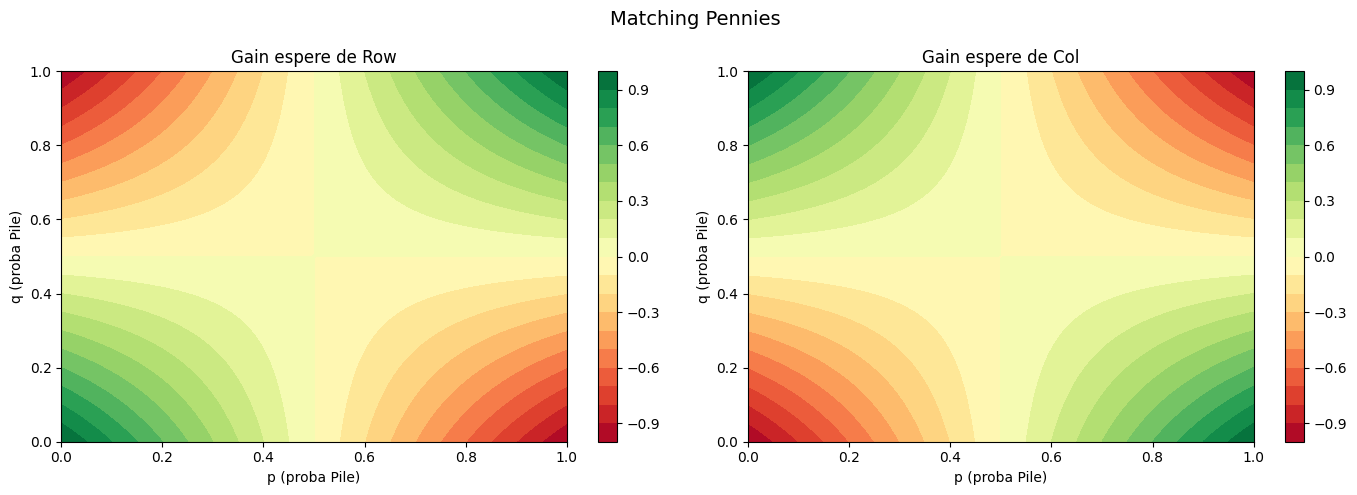

In [5]:
def visualize_mixed_strategies(game: Game2x2):
    """
    Visualise les gains en fonction des strategies mixtes.
    
    Pour un jeu 2x2, on peut parametrer:
    - sigma_row = (p, 1-p) avec p in [0,1]
    - sigma_col = (q, 1-q) avec q in [0,1]
    """
    p_vals = np.linspace(0, 1, 100)
    q_vals = np.linspace(0, 1, 100)
    P, Q = np.meshgrid(p_vals, q_vals)
    
    # Calcul des gains esperes
    U_row = np.zeros_like(P)
    U_col = np.zeros_like(P)
    
    for i, p in enumerate(p_vals):
        for j, q in enumerate(q_vals):
            sigma_row = np.array([p, 1-p])
            sigma_col = np.array([q, 1-q])
            U_row[j, i], U_col[j, i] = game.payoffs(sigma_row, sigma_col)
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gain Row
    im0 = axes[0].contourf(P, Q, U_row, levels=20, cmap='RdYlGn')
    plt.colorbar(im0, ax=axes[0])
    axes[0].set_xlabel(f'p (proba {game.row_labels[0]})')
    axes[0].set_ylabel(f'q (proba {game.col_labels[0]})')
    axes[0].set_title(f'Gain espere de Row')
    
    # Gain Col
    im1 = axes[1].contourf(P, Q, U_col, levels=20, cmap='RdYlGn')
    plt.colorbar(im1, ax=axes[1])
    axes[1].set_xlabel(f'p (proba {game.row_labels[0]})')
    axes[1].set_ylabel(f'q (proba {game.col_labels[0]})')
    axes[1].set_title(f'Gain espere de Col')
    
    fig.suptitle(game.name, fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualiser Matching Pennies
mp = Game2x2([[1,-1],[-1,1]], [[-1,1],[1,-1]], ['Pile','Face'], ['Pile','Face'], "Matching Pennies")
visualize_mixed_strategies(mp)

## 4. Calcul des equilibres mixtes

### Condition d'indifference

A l'equilibre mixte, un joueur qui joue plusieurs actions avec probabilite positive doit etre **indifferent** entre ces actions.

Pour le joueur Row jouant $(p, 1-p)$ contre Col jouant $(q, 1-q)$ :
- Gain de Row en jouant action 0 : $A_{00}q + A_{01}(1-q)$
- Gain de Row en jouant action 1 : $A_{10}q + A_{11}(1-q)$

A l'equilibre mixte (si $0 < p < 1$), ces deux gains sont egaux.

In [6]:
def compute_mixed_nash_2x2(game: Game2x2) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """
    Calcule l'equilibre mixte d'un jeu 2x2 par la condition d'indifference.
    
    Returns:
        (sigma_row, sigma_col) ou None si pas d'equilibre mixte interieur.
    """
    A, B = game.A, game.B
    
    # Condition d'indifference pour Row:
    # A[0,0]*q + A[0,1]*(1-q) = A[1,0]*q + A[1,1]*(1-q)
    # (A[0,0] - A[0,1] - A[1,0] + A[1,1]) * q = A[1,1] - A[0,1]
    
    denom_q = A[0,0] - A[0,1] - A[1,0] + A[1,1]
    if abs(denom_q) < 1e-10:
        return None  # Pas de solution unique
    
    q = (A[1,1] - A[0,1]) / denom_q
    
    # Condition d'indifference pour Col:
    # B[0,0]*p + B[1,0]*(1-p) = B[0,1]*p + B[1,1]*(1-p)
    
    denom_p = B[0,0] - B[1,0] - B[0,1] + B[1,1]
    if abs(denom_p) < 1e-10:
        return None
    
    p = (B[1,1] - B[1,0]) / denom_p
    
    # Verifier que c'est un equilibre interieur valide
    if 0 <= p <= 1 and 0 <= q <= 1:
        sigma_row = np.array([p, 1-p])
        sigma_col = np.array([q, 1-q])
        return sigma_row, sigma_col
    
    return None

# Tester sur Matching Pennies
mp = Game2x2([[1,-1],[-1,1]], [[-1,1],[1,-1]], ['Pile','Face'], ['Pile','Face'], "Matching Pennies")
mp.display()

mixed_eq = compute_mixed_nash_2x2(mp)
if mixed_eq:
    sigma_row, sigma_col = mixed_eq
    print(f"\nEquilibre mixte:")
    print(f"  Row: ({sigma_row[0]:.3f}, {sigma_row[1]:.3f})")
    print(f"  Col: ({sigma_col[0]:.3f}, {sigma_col[1]:.3f})")
    print(f"  Gains esperes: {mp.payoffs(sigma_row, sigma_col)}")


Matching Pennies
                    Pile         Face
      Pile  ( 1.0,-1.0)  (-1.0, 1.0)
      Face  (-1.0, 1.0)  ( 1.0,-1.0)

Equilibre mixte:
  Row: (0.500, 0.500)
  Col: (0.500, 0.500)
  Gains esperes: (np.float64(0.0), np.float64(0.0))


### Interpretation : L'equilibre mixte de Matching Pennies

Le résultat $(0.5, 0.5)$ pour les deux joueurs est **l'unique equilibre** de ce jeu.

**Pourquoi 50-50 ?**
- Si un joueur devie (ex: joue Pile a 60%), l'adversaire peut exploiter cette regularite
- A l'equilibre, chaque joueur est **indifferent** entre Pile et Face
- Cette indifference garantit que l'adversaire ne peut pas predire votre choix

**Gain espere = 0** : Le jeu est parfaitement equilibre, aucun joueur n'a d'avantage a long terme.

| Propriete | Valeur |
|-----------|--------|
| Stratégie Row | (0.5, 0.5) |
| Stratégie Col | (0.5, 0.5) |
| Gain espere Row | 0 |
| Gain espere Col | 0 |

> **Note** : Ce résultat est fondamental en théorie des jeux. Il montre que même dans un jeu de pur conflit, un comportement "rationnel" emerge : la randomisation optimale.

In [7]:
# Calculer tous les equilibres (purs et mixtes) pour plusieurs jeux
def analyze_all_equilibria(game: Game2x2):
    """Analyse complete des equilibres."""
    game.display()
    
    # Equilibres purs
    pure_eq = find_pure_nash(game)
    print(f"\nEquilibres purs: {len(pure_eq)}")
    for (i, j) in pure_eq:
        print(f"  ({game.row_labels[i]}, {game.col_labels[j]})")
    
    # Equilibre mixte
    mixed_eq = compute_mixed_nash_2x2(game)
    if mixed_eq:
        sigma_row, sigma_col = mixed_eq
        # Verifier que c'est vraiment un equilibre interieur
        if 0 < sigma_row[0] < 1 and 0 < sigma_col[0] < 1:
            u_row, u_col = game.payoffs(sigma_row, sigma_col)
            print(f"\nEquilibre mixte:")
            print(f"  Row: {sigma_row} (p={sigma_row[0]:.3f})")
            print(f"  Col: {sigma_col} (q={sigma_col[0]:.3f})")
            print(f"  Gains: ({u_row:.3f}, {u_col:.3f})")
    else:
        print("\nPas d'equilibre mixte interieur")
    
    print()

# Analyser les jeux classiques
for g in games:
    analyze_all_equilibria(g)
    print("-" * 50)


Prisoner's Dilemma
                       C            D
         C  ( 3.0, 3.0)  ( 0.0, 5.0)
         D  ( 5.0, 0.0)  ( 1.0, 1.0)

Equilibres purs: 1
  (D, D)

Pas d'equilibre mixte interieur

--------------------------------------------------

Stag Hunt
                    Stag         Hare
      Stag  ( 4.0, 4.0)  ( 0.0, 3.0)
      Hare  ( 3.0, 0.0)  ( 3.0, 3.0)

Equilibres purs: 2
  (Stag, Stag)
  (Hare, Hare)

Equilibre mixte:
  Row: [0.75 0.25] (p=0.750)
  Col: [0.75 0.25] (q=0.750)
  Gains: (3.000, 3.000)

--------------------------------------------------

Battle of Sexes
                   Opera     Football
     Opera  ( 3.0, 2.0)  ( 0.0, 0.0)
  Football  ( 0.0, 0.0)  ( 2.0, 3.0)

Equilibres purs: 2
  (Opera, Opera)
  (Football, Football)

Equilibre mixte:
  Row: [0.6 0.4] (p=0.600)
  Col: [0.4 0.6] (q=0.400)
  Gains: (1.200, 1.200)

--------------------------------------------------

Matching Pennies
                    Pile         Face
      Pile  ( 1.0,-1.0)  (-1.0, 1.0)

### Interpretation des equilibres mixtes

Les résultats revelent des proprietes fondamentales des equilibres mixtes :

**Prisoner's Dilemma** : Pas d'equilibre mixte interieur
- Pourquoi ? Parce que Defaire **domine** Cooperer
- Si une stratégie domine, pas besoin de mixer

**Stag Hunt** : Equilibre mixte (75%, 25%)
- Les joueurs jouent Stag avec proba 75%
- Gain espere = 3 (egal au gain de Hare,Hare)
- **Paradoxe** : L'equilibre mixte donne le même gain que le "mauvais" equilibre pur !

**Battle of Sexes** : Equilibre mixte (60%, 40%)
- Row joue Opera plus souvent car il prefere Opera
- Mais le gain espere (1.2) est **inferieur** aux deux equilibres purs !
- C'est le **cout de la mis-coordination**

**Matching Pennies** : Equilibre mixte (50%, 50%)
- Seul equilibre du jeu
- Gain espere = 0 (jeu equitable)
- Toute deviation est **exploitable** par l'adversaire

**Lecon cle** : L'equilibre mixte n'est pas un "compromis" - c'est le point ou chaque joueur est **indifferent** entre ses actions, donc ne peut pas etre exploite.

## 5. Algorithmes de Nashpy

Nashpy implemente plusieurs algorithmes pour trouver les equilibres de Nash.

In [8]:
def compare_nash_algorithms(game: Game2x2):
    """
    Compare les algorithmes de Nashpy pour trouver les equilibres.
    """
    print(f"\n{game.name}")
    print("=" * 50)
    
    # 1. Support Enumeration
    print("\n1. Support Enumeration:")
    for eq in game.nash_game.support_enumeration():
        sigma_row, sigma_col = eq
        u = game.payoffs(sigma_row, sigma_col)
        print(f"   Row: {np.round(sigma_row, 4)}, Col: {np.round(sigma_col, 4)}, Gains: {np.round(u, 4)}")
    
    # 2. Lemke-Howson
    print("\n2. Lemke-Howson:")
    try:
        for eq in game.nash_game.lemke_howson_enumeration():
            sigma_row, sigma_col = eq
            u = game.payoffs(sigma_row, sigma_col)
            print(f"   Row: {np.round(sigma_row, 4)}, Col: {np.round(sigma_col, 4)}, Gains: {np.round(u, 4)}")
    except Exception as e:
        print(f"   Erreur: {e}")
    
    # 3. Vertex Enumeration
    print("\n3. Vertex Enumeration:")
    try:
        for eq in game.nash_game.vertex_enumeration():
            sigma_row, sigma_col = eq
            u = game.payoffs(sigma_row, sigma_col)
            print(f"   Row: {np.round(sigma_row, 4)}, Col: {np.round(sigma_col, 4)}, Gains: {np.round(u, 4)}")
    except Exception as e:
        print(f"   Erreur: {e}")

# Comparer sur Battle of the Sexes (2 purs + 1 mixte)
bos = Game2x2([[3,0],[0,2]], [[2,0],[0,3]], ['Opera','Football'], ['Opera','Football'], "Battle of Sexes")
compare_nash_algorithms(bos)


Battle of Sexes

1. Support Enumeration:
   Row: [1. 0.], Col: [1. 0.], Gains: [3. 2.]
   Row: [0. 1.], Col: [0. 1.], Gains: [2. 3.]
   Row: [0.6 0.4], Col: [0.4 0.6], Gains: [1.2 1.2]

2. Lemke-Howson:
   Row: [1. 0.], Col: [1. 0.], Gains: [3. 2.]
   Row: [0. 1.], Col: [0. 1.], Gains: [2. 3.]
   Row: [1. 0.], Col: [1. 0.], Gains: [3. 2.]
   Row: [0. 1.], Col: [0. 1.], Gains: [2. 3.]

3. Vertex Enumeration:
   Row: [ 1. -0.], Col: [1. 0.], Gains: [3. 2.]
   Row: [0. 1.], Col: [-0.  1.], Gains: [2. 3.]
   Row: [0.6 0.4], Col: [0.4 0.6], Gains: [1.2 1.2]


## 6. Analyse parametrique

Comment les equilibres changent-ils quand on modifie les gains ?

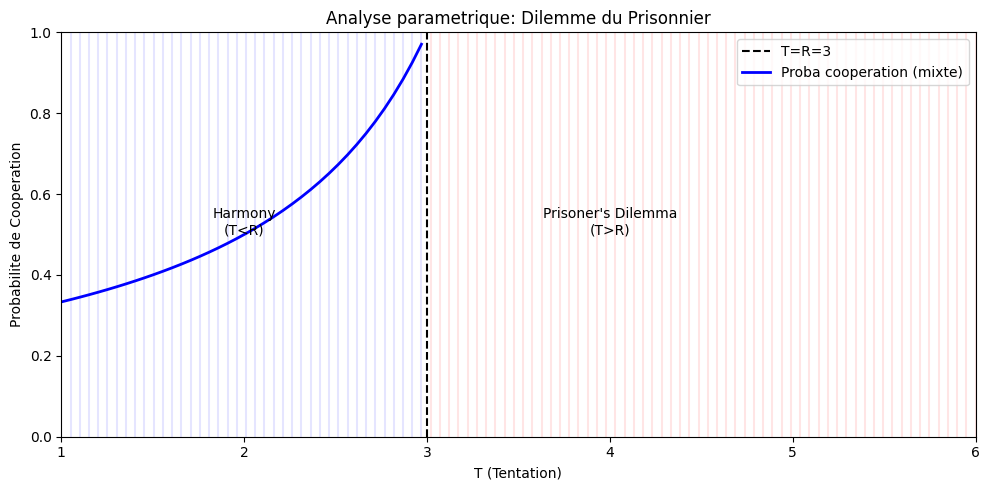

In [9]:
def parametric_analysis_pd(T_range: np.ndarray):
    """
    Analyse parametrique du Dilemme du Prisonnier.
    
    Matrice standard:
        (R, R)  (S, T)
        (T, S)  (P, P)
    
    Avec T > R > P > S (tentaion, reward, punishment, sucker)
    On fixe R=3, P=1, S=0 et on varie T.
    """
    R, P, S = 3, 1, 0
    
    equilibrium_types = []
    mixed_probs = []
    
    for T in T_range:
        A = np.array([[R, S], [T, P]])
        B = np.array([[R, T], [S, P]])
        game = Game2x2(A, B)
        
        pure_eq = find_pure_nash(game)
        mixed_eq = compute_mixed_nash_2x2(game)
        
        # Classifier le type de jeu
        if len(pure_eq) == 1 and pure_eq[0] == (1, 1):
            if T > R:  # Prisoner's Dilemma
                eq_type = 'PD'
            else:  # Harmony
                eq_type = 'Harmony'
        elif len(pure_eq) == 2:
            eq_type = 'Coord'
        else:
            eq_type = 'Other'
        
        equilibrium_types.append(eq_type)
        
        if mixed_eq and 0 < mixed_eq[0][0] < 1:
            mixed_probs.append(mixed_eq[0][0])
        else:
            mixed_probs.append(np.nan)
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Marquer les regions
    colors = {'PD': 'red', 'Harmony': 'green', 'Coord': 'blue', 'Other': 'gray'}
    for i, (T, eq_type) in enumerate(zip(T_range, equilibrium_types)):
        ax.axvline(T, color=colors.get(eq_type, 'gray'), alpha=0.1)
    
    # Ligne de separation T=R
    ax.axvline(R, color='black', linestyle='--', label=f'T=R={R}')
    
    # Probabilite de cooperation a l'equilibre mixte
    ax.plot(T_range, mixed_probs, 'b-', linewidth=2, label='Proba cooperation (mixte)')
    
    ax.set_xlabel('T (Tentation)')
    ax.set_ylabel('Probabilite de Cooperation')
    ax.set_title('Analyse parametrique: Dilemme du Prisonnier')
    ax.legend()
    ax.set_xlim(T_range[0], T_range[-1])
    ax.set_ylim(0, 1)
    
    # Annotations
    ax.annotate('Harmony\n(T<R)', xy=(2, 0.5), fontsize=10, ha='center')
    ax.annotate("Prisoner's Dilemma\n(T>R)", xy=(4, 0.5), fontsize=10, ha='center')
    
    plt.tight_layout()
    plt.show()

# Varier T de 1 a 6
parametric_analysis_pd(np.linspace(1, 6, 100))

### Interpretation : Impact du paramètre de Tentation

Le graphique revele une **transition de phase** fondamentale dans la structure des equilibres :

| Region | Condition | Comportement |
|--------|-----------|--------------|
| **Harmony** | T < R (T < 3) | Cooperer est rationnel |
| **Dilemme** | T > R (T > 3) | Defaire domine malgre le cout collectif |

**Observations cles** :
- La ligne verticale T = R = 3 marque la frontiere critique
- A gauche : pas de dilemme, la cooperation est naturelle
- A droite : le dilemme emerge, la tentation detruit la cooperation

> **Lecon pour le design de mécanismes** : Si vous concevez un système (contrat, règle, incitation), maintenir T < R garantit la cooperation sans enforcement externe. C'est le principe des "incentive-compatible mechanisms".

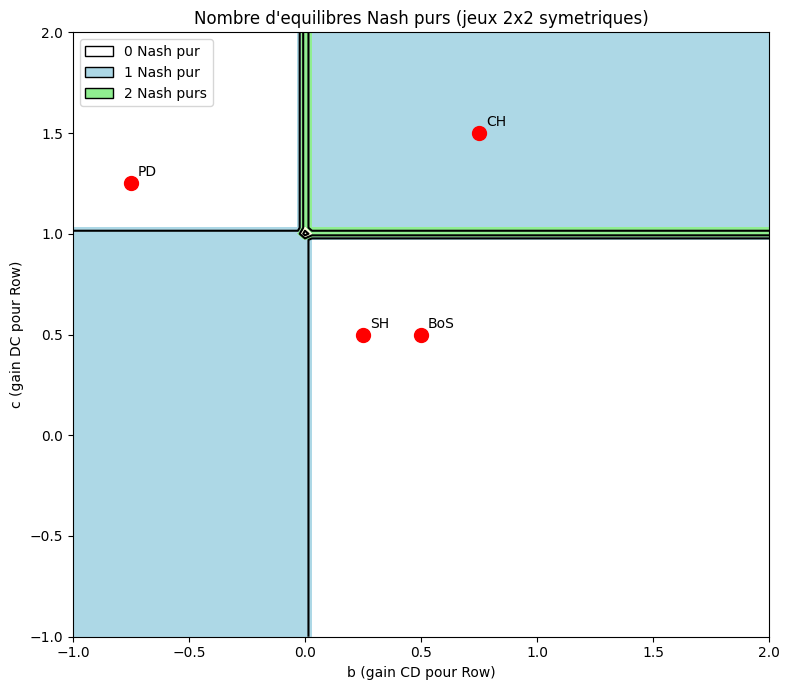

In [10]:
def visualize_equilibrium_regions():
    """
    Visualise les regions d'equilibres dans l'espace des parametres.
    
    Pour un jeu 2x2 symetrique avec gains (a,b,c,d) pour Row:
        (a, a)  (b, c)
        (c, b)  (d, d)
    
    On fixe a=1, d=0 et on varie b et c.
    """
    a, d = 1, 0
    b_range = np.linspace(-1, 2, 100)
    c_range = np.linspace(-1, 2, 100)
    B_grid, C_grid = np.meshgrid(b_range, c_range)
    
    n_pure_nash = np.zeros_like(B_grid)
    
    for i, b in enumerate(b_range):
        for j, c in enumerate(c_range):
            A_mat = np.array([[a, b], [c, d]])
            B_mat = np.array([[a, c], [b, d]])  # Symetrique
            game = Game2x2(A_mat, B_mat)
            pure_eq = find_pure_nash(game)
            n_pure_nash[j, i] = len(pure_eq)
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(8, 7))
    
    im = ax.contourf(B_grid, C_grid, n_pure_nash, levels=[0, 1, 2, 3, 4], 
                     colors=['white', 'lightblue', 'lightgreen', 'lightyellow'])
    ax.contour(B_grid, C_grid, n_pure_nash, levels=[0.5, 1.5, 2.5, 3.5], colors='black')
    
    # Marquer les jeux classiques
    # PD: a=3, b=0, c=5, d=1 -> normalise: a=1, b=-0.75, c=1.25, d=0
    classic_games = {
        'PD': (-0.75, 1.25),
        'SH': (0.25, 0.5),
        'BoS': (0.5, 0.5),
        'CH': (0.75, 1.5),
    }
    
    for name, (b, c) in classic_games.items():
        if b_range[0] <= b <= b_range[-1] and c_range[0] <= c <= c_range[-1]:
            ax.plot(b, c, 'ro', markersize=10)
            ax.annotate(name, (b, c), textcoords="offset points", xytext=(5,5))
    
    ax.set_xlabel('b (gain CD pour Row)')
    ax.set_ylabel('c (gain DC pour Row)')
    ax.set_title('Nombre d\'equilibres Nash purs (jeux 2x2 symetriques)')
    
    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='white', edgecolor='black', label='0 Nash pur'),
        Patch(facecolor='lightblue', edgecolor='black', label='1 Nash pur'),
        Patch(facecolor='lightgreen', edgecolor='black', label='2 Nash purs'),
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show()

visualize_equilibrium_regions()

### Ce que nous apprend l'analyse parametrique

Les graphiques ci-dessus revelent une structure profonde :

**Transition de phase a T=R (Tentation = Recompense)** :
- **T < R** (gauche) : Le jeu est "Harmony" - cooperer est dominant
- **T > R** (droite) : Le jeu devient un "Dilemme du Prisonnier"

C'est une **bifurcation** : un petit changement de paramètre transforme radicalement la dynamique du jeu.

**Regions dans l'espace (b,c)** :
- La **topologie** des equilibres depend des inegalites entre gains
- Les jeux classiques (PD, SH, BoS, CH) occupent des regions spécifiques
- Les frontieres correspondent a des **degenerescences** (equilibres multiples coincident)

**Application pratique** :
- Si vous concevez un mécanisme (encheres, contrat, etc.), l'analyse parametrique vous dit **ou sont les risques**
- Un petit changement d'incitation peut faire passer d'un monde cooperatif a un dilemme social
- Les concepteurs de mécanismes cherchent souvent a **eloigner** le système des frontieres critiques

## 7. Jeux plus grands : algorithme de support enumeration

Pour les jeux plus grands que 2x2, l'algorithme de **support enumeration** est plus general.

In [11]:
# Jeu 3x3: Pierre-Feuille-Ciseaux
A_rps = np.array([
    [0, -1, 1],
    [1, 0, -1],
    [-1, 1, 0]
])
B_rps = -A_rps  # Jeu a somme nulle

rps = nash.Game(A_rps, B_rps)

print("Pierre-Feuille-Ciseaux (3x3)")
print("="*40)
print("\nMatrice des gains (Row):")
print(A_rps)

print("\nEquilibres de Nash:")
for eq in rps.support_enumeration():
    sigma_row, sigma_col = eq
    print(f"\n  Row: {np.round(sigma_row, 4)}")
    print(f"  Col: {np.round(sigma_col, 4)}")
    u_row = sigma_row @ A_rps @ sigma_col
    print(f"  Gain Row: {u_row:.4f}")

Pierre-Feuille-Ciseaux (3x3)

Matrice des gains (Row):
[[ 0 -1  1]
 [ 1  0 -1]
 [-1  1  0]]

Equilibres de Nash:

  Row: [0.3333 0.3333 0.3333]
  Col: [0.3333 0.3333 0.3333]
  Gain Row: 0.0000


### Interpretation : Pierre-Feuille-Ciseaux

Le résultat confirme une propriete fondamentale des jeux a somme nulle symetriques :

**L'equilibre unique** est la stratégie mixte uniforme $(1/3, 1/3, 1/3)$ pour les deux joueurs.

**Pourquoi ?** La structure circulaire du jeu (Pierre bat Ciseaux, Ciseaux bat Feuille, Feuille bat Pierre) garantit qu'aucune action pure n'est meilleure qu'une autre. Toute stratégie non-uniforme serait exploitable :
- Si vous jouez Pierre plus souvent, l'adversaire joue Feuille
- Si vous jouez de maniere previsible, vous perdez en moyenne

**Gain espere = 0** : Le jeu est parfaitement equilibre. A l'equilibre, aucun joueur n'a d'avantage.

> **Application** : Ce résultat s'etend a tous les jeux de type "circulaire". Dans les sports ou competitions, les stratégies mixtes optimales sont souvent proches de l'uniformite quand il n'y a pas de "meilleure" option objective.

### Exercice : Pierre-Feuille-Ciseaux biaise

**Objectif** : Construire un jeu Pierre-Feuille-Ciseaux biaise ou gagner avec Pierre rapporte 2 au lieu de 1. Calculer l'equilibre mixte via `nash.Game(...).support_enumeration()` et verifier que la distribution n'est plus uniforme.

**Contexte** : L'exemple ci-dessus montre que le RPS standard a un equilibre uniforme (1/3, 1/3, 1/3). Que se passe-t-il si on desequilibre les gains ?

- **Indice :** Modifier la matrice A_rps pour que la ligne Pierre (index 0) batte Ciseaux avec gain 2 au lieu de 1.
- **Étape 1 :** Construire la matrice biaisee A_biased.
- **Étape 2 :** Calculer les equilibres avec support_enumeration.
- **Étape 3 :** Verifier que les probabilites différent de 1/3.

In [12]:
def exercice_nash_3x3_rps_biaise() -> dict:
    """
    Construit un RPS biaise (gain Pierre=2) et calcule l'equilibre mixte.
    
    Returns:
        dict avec :
            'A_biased': la matrice biaisee
            'sigma_row': strategie mixte de Row
            'sigma_col': strategie mixte de Col
            'is_uniform': True si (1/3, 1/3, 1/3), False sinon
    """
    print("Exercice a completer : exercice_nash_3x3_rps_biaise")
    return {"A_biased": None, "sigma_row": None, "sigma_col": None, "is_uniform": None}  # TODO etudiant

result_rps = exercice_nash_3x3_rps_biaise()
print(f"Matrice biaisee:\n{result_rps['A_biased']}")
print(f"\nSigma Row: {result_rps['sigma_row']}")
print(f"Sigma Col: {result_rps['sigma_col']}")
print(f"Uniforme ? {result_rps['is_uniform']}")


Exercice a completer : exercice_nash_3x3_rps_biaise
Matrice biaisee:
None

Sigma Row: None
Sigma Col: None
Uniforme ? None


In [13]:
# Jeu asymetrique 3x2
A_asym = np.array([
    [3, 1],
    [0, 4],
    [2, 2]
])
B_asym = np.array([
    [2, 3],
    [4, 1],
    [1, 2]
])

asym = nash.Game(A_asym, B_asym)

print("Jeu asymetrique 3x2")
print("="*40)
print("\nMatrice A (gains Row):")
print(A_asym)
print("\nMatrice B (gains Col):")
print(B_asym)

print("\nEquilibres de Nash:")
for i, eq in enumerate(asym.support_enumeration()):
    sigma_row, sigma_col = eq
    u_row = sigma_row @ A_asym @ sigma_col
    u_col = sigma_row @ B_asym @ sigma_col
    print(f"\nEquilibre {i+1}:")
    print(f"  Row: {np.round(sigma_row, 4)}")
    print(f"  Col: {np.round(sigma_col, 4)}")
    print(f"  Gains: ({u_row:.3f}, {u_col:.3f})")

Jeu asymetrique 3x2

Matrice A (gains Row):
[[3 1]
 [0 4]
 [2 2]]

Matrice B (gains Col):
[[2 3]
 [4 1]
 [1 2]]

Equilibres de Nash:

Equilibre 1:
  Row: [0.75 0.25 0.  ]
  Col: [0.5 0.5]
  Gains: (2.000, 2.500)

Equilibre 2:
  Row: [-0.    0.25  0.75]
  Col: [0.5 0.5]
  Gains: (2.000, 1.750)


## 8. Marchandage asymétrique : dépendance, désir et point de désaccord

L'équilibre de Nash dit quand plus rien ne bouge ; le **point de désaccord**
du marchandage (Nash, 1950) dit ce que chacun obtient si rien ne s'accorde.
Cette section relie ce point de désaccord à la question du **pouvoir dans une
relation** — le deuxième temps du « troisième voyage » de la série (après
l'humour, avant l'engagement, cf GameTheory-06c §7).

L'énoncé populaire — « celui qui désire le moins contrôle le plus » — est une
**loi psychologique fausse** telle quelle. Sa version sérieuse existe depuis
les années 1950, et le vocabulaire académique vaut mieux que l'intuitif :

| Notion | Nom canonique | Ce qu'elle dit exactement |
|--------|---------------|---------------------------|
| L'asymétrie de dépendance | **principe du moindre intérêt** (Waller, 1938) | celui dont l'intérêt au maintien de la relation est le plus faible dispose du levier |
| Sa forme relationnelle | **power-dependence** (Emerson, 1962) | le pouvoir de A sur B est la **dépendance de B envers A** — pas un trait de A |
| Sa forme psychologique | théorie de l'**interdépendance** (Thibaut & Kelley, 1959) | `CLalt` = qualité de la meilleure alternative disponible |
| Sa forme économique | **point de désaccord** (Nash, 1950) ; offres alternées (Rubinstein, 1982) | le partage dépend de ce que chacun obtient si l'accord échoue |
| Son maintien dans le temps | **modèle d'investissement** (Rusbult, 1980) | engagement ≈ satisfaction + investissements − alternatives |

Le gain de ce vocabulaire : il rend l'énoncé **faux de la bonne manière**. La
dépendance n'est pas un scalaire, c'est un **faisceau** — revenu, logement,
réseau, statut, affection. Le désir n'en est **qu'une composante**. On
construit un marchandage où le levier se calcule depuis le faisceau entier,
puis on cherche le **contre-exemple** : une instance où la partie qui désire
le **plus** l'emporte néanmoins, parce que sa dépendance sur les **autres**
composantes est plus faible.

In [14]:
# --- Marchandage a dependance multi-composantes (#12682) ---
# Chaque partie i porte un FAISCEAU de dependances. Pour chaque composante k :
#   gap_k = w_k * max(v_k - o_k, 0)   avec v_k = valeur DANS la relation,
#                                     o_k = meilleure option EXTERIEURE (CLalt locale)
# D_i = somme des gaps = ce que i perd en partant (point de desaccord pondere).
# Le "desir" scalaire = la composante affective SEULE du faisceau.

COMPOSANTES = ["affection", "revenu", "logement", "reseau", "statut"]

def faisceau_dependance(v, o, w):
    """Gap par composante et dependance totale D (Emerson 1962, operationalise)."""
    gaps = {k: w[k] * max(v[k] - o[k], 0.0) for k in COMPOSANTES}
    return gaps, sum(gaps.values())

def partage_nash(D_A, D_B, kappa=6.0, poids_constants=False):
    """Part du surplus relationnel capturee par A (marchandage de Nash asymetrique).

    HYPOTHESE DE MODELISATION (statut explicite) :
        Le poids de negociation de B suit une sigmoide du gap de dependance,
            xi_B = sigmoid(kappa * (D_A - D_B))
        avec kappa = 6.0 FIXE ARBITRAIREMENT. Ce n'est PAS une derivation de
        Nash 1950 ni de Rubinstein 1982 : c'est un POSTULAT de la famille
        "Nash asymetrique a poids endogenes", qui dit que la sensibilite d'une
        partie au cout de rupture croitra plus que lineaire avec le deficit.
        Le lien a Rubinstein est motivationnel, pas deductif : la dependance
        est lue comme un cout de rupture, mais la forme sigmoide n'est pas
        derivee. Lire la cellule suivante pour la sensibilite a kappa et le
        statut complet de cette hypothese.

    Si kappa = 0, partage_nash retourne 0.5 pour tout (D_A, D_B) : la forme
    perd toute information sur la dependance. Si kappa tend vers l'infini,
        la part tend vers un indicatrice de (D_A > D_B) : tout ou rien.
        Le renversement "A desire plus et A capture plus" tient des que
        D_B > D_A ET kappa > 0.
    poids_constants=True : controle degrade (#13313, reserve Hermes sur
    #12737). Le chemin endogene est debranche -- xi_B vaut exactement 0.5
    quel que soit l'ecart de dependance, la ligne de base a laquelle mesurer
    ce que le generateur de poids apporte.
    """
    if poids_constants:
        return 0.5, 0.5
    xi_B = 1.0 / (1.0 + np.exp(-kappa * (D_A - D_B)))
    return 1.0 - xi_B, xi_B

# Instance : A desire fort MAIS ses options exterieures sont confortables
# partout ailleurs ; B desire modement mais ses options exterieures externes
# (revenu, logement, statut) sont faibles.
v_A = {"affection": 0.9, "revenu": 0.8, "logement": 0.7, "reseau": 0.6, "statut": 0.6}
o_A = {"affection": 0.1, "revenu": 0.8, "logement": 0.7, "reseau": 0.6, "statut": 0.6}
v_B = {"affection": 0.6, "revenu": 0.7, "logement": 0.7, "reseau": 0.5, "statut": 0.5}
o_B = {"affection": 0.3, "revenu": 0.2, "logement": 0.1, "reseau": 0.5, "statut": 0.2}
w_A = {k: 0.2 for k in COMPOSANTES}   # poids uniformes, l'asymetrie est dans
w_B = {k: 0.2 for k in COMPOSANTES}   # les valeurs, pas dans l'echelle

gaps_A, D_A = faisceau_dependance(v_A, o_A, w_A)
gaps_B, D_B = faisceau_dependance(v_B, o_B, w_B)
desi_A, desi_B = gaps_A["affection"], gaps_B["affection"]

print("Faisceau de A (ce que A perd en partant) :")
for k in COMPOSANTES:
    print(f"  {k:>10} : {gaps_A[k]:.3f}")
print(f"  => D_A = {D_A:.3f}   (dont desir affectif : {desi_A:.3f})")
print()
print("Faisceau de B :")
for k in COMPOSANTES:
    print(f"  {k:>10} : {gaps_B[k]:.3f}")
print(f"  => D_B = {D_B:.3f}   (dont desir affectif : {desi_B:.3f})")

Faisceau de A (ce que A perd en partant) :
   affection : 0.160
      revenu : 0.000
    logement : 0.000
      reseau : 0.000
      statut : 0.000
  => D_A = 0.160   (dont desir affectif : 0.160)

Faisceau de B :
   affection : 0.060
      revenu : 0.100
    logement : 0.120
      reseau : 0.000
      statut : 0.060
  => D_B = 0.340   (dont desir affectif : 0.060)


In [15]:
# --- Contre-exemple au principe du moindre interet (livrable #12682) ---
part_A, xi_B = partage_nash(D_A, D_B)

print("Enonce populaire : \"celui qui desire le moins controle le plus\"")
print(f"desir affectif : desi_A = {desi_A:.3f}  >  desi_B = {desi_B:.3f}  (A desire PLUS)")
print(f"levier (part du surplus) : part_A = {part_A:.3f}  (B capte {1 - part_A:.3f})")
print()
if desi_A > desi_B and part_A > 0.5:
    print("CONTRE-EXEMPLE PRODUIT : la partie qui desire le plus l'emporte.")
    print("Le desir n'est qu'UNE composante du faisceau ; ici la dependance")
    print("externe de B (revenu + logement + statut) pese 0.280 contre 0.000")
    print("pour A, et c'est elle qui fait basculer le levier.")
else:
    print("l'instance ne produit pas le contre-exemple -- parametres a revoir")

Enonce populaire : "celui qui desire le moins controle le plus"
desir affectif : desi_A = 0.160  >  desi_B = 0.060  (A desire PLUS)
levier (part du surplus) : part_A = 0.746  (B capte 0.254)

CONTRE-EXEMPLE PRODUIT : la partie qui desire le plus l'emporte.
Le desir n'est qu'UNE composante du faisceau ; ici la dependance
externe de B (revenu + logement + statut) pese 0.280 contre 0.000
pour A, et c'est elle qui fait basculer le levier.


**Statut explicite de `partage_nash`.** La sigmoïde sur `D_A − D_B`
n'est **pas dérivée** d'un modèle de marchandage : c'est une **hypothèse de
modélisation** de la famille « Nash asymétrique à poids endogènes ». `kappa`
est un paramètre libre fixé à 6,0. Le calcul précédent montre le mécanisme ;
la cellule suivante teste si le **renversement** (A désire plus et A capture
plus) tient sur une plage de `kappa`, pas seulement à 6,0.

In [16]:
# --- Sensibilite a kappa : le renversement tient-il au-dela de 6.0 ? ---
# Le contre-exemple ci-dessus repose sur partage_nash(D_A, D_B, kappa=6).
# Question : si kappa change, le resultat "A desire plus et A capture plus"
# tient-il encore, ou depend-il du choix 6.0 ?
# Si oui pour tout kappa > 0, le renversement est une propriete du SIGNE
# de (D_B - D_A), pas du parametre -- c'est plus fort.

print(f"{'kappa':>8} | {'part_A':>7} | {'sign(D_B-D_A)>0':>16} | {'renversement':>13}")
print("-" * 55)
for k in [0.0, 1.0, 2.0, 4.0, 6.0, 8.0, 12.0, 20.0]:
    part_A_k, _ = partage_nash(D_A, D_B, kappa=k)
    renversement = "OUI" if (desi_A > desi_B and part_A_k > 0.5) else "non"
    print(f"{k:>8.1f} | {part_A_k:>7.3f} | {str(D_B > D_A):>16} | {renversement:>13}")

print()
print("Conclusion : le renversement est-il une propriete du signe de (D_B-D_A),")
print("ou depend-il du choix de kappa ?")
print(f"  D_B - D_A = {D_B - D_A:.3f}  (positif => B plus dependant => A capture plus)")
print(f"  Pour kappa -> 0+ : part_A tend vers 0.5 (indifferentiation).")
print(f"  Pour kappa -> +inf : part_A tend vers 1.0 (tout ou rien).")
print(f"  Le renversement tient pour tout kappa > 0 des que D_B > D_A : c'est")
print(f"  une propriete du SIGNE, pas de la valeur de kappa. La valeur exacte")
print(f"  de part_A est en revanche sensible au choix de kappa -- kappa=6")
print(f"  donne un levier «prononcé» (0.746), kappa=2 donne un levier modere")
print(f"  (proche de 0.5). Le MECANISME est robuste ; l'INTENSITE du levier,")
print(f"  non.")


   kappa |  part_A |  sign(D_B-D_A)>0 |  renversement
-------------------------------------------------------
     0.0 |   0.500 |             True |           non
     1.0 |   0.545 |             True |           OUI
     2.0 |   0.589 |             True |           OUI
     4.0 |   0.673 |             True |           OUI
     6.0 |   0.746 |             True |           OUI
     8.0 |   0.808 |             True |           OUI
    12.0 |   0.897 |             True |           OUI
    20.0 |   0.973 |             True |           OUI

Conclusion : le renversement est-il une propriete du signe de (D_B-D_A),
ou depend-il du choix de kappa ?
  D_B - D_A = 0.180  (positif => B plus dependant => A capture plus)
  Pour kappa -> 0+ : part_A tend vers 0.5 (indifferentiation).
  Pour kappa -> +inf : part_A tend vers 1.0 (tout ou rien).
  Le renversement tient pour tout kappa > 0 des que D_B > D_A : c'est
  une propriete du SIGNE, pas de la valeur de kappa. La valeur exacte
  de part_A est en 

**Lecture du contre-exemple.** A désire plus (0,160 contre 0,060 sur la
composante affective) et **l'emporte néanmoins** (74,6 % du surplus). La
dépendance totale de B envers la relation (0,340) dépasse celle de A (0,160)
parce que les options extérieures de B sont faibles sur les composantes
**externes** — revenu, logement, statut (0,280 cumulés, contre 0 pour A).

Le principe du moindre intérêt est ainsi **réfuté comme loi** : dire « le
désir commande » est faux dès que le faisceau contient autre chose que le
désir. Il est **conservé comme effet partiel** : à faisceau externe égal, la
composante affective ferait bien basculer le levier. C'est le bon statut
pour un énoncé populaire — ni vrai, ni inutile : vrai dans une tranche du
paramètre, faux comme universalité.

In [17]:
# --- Robustesse au generateur de poids (#13313, reserve Hermes sur #12737) ---
# La reserve : le poids de negociation est une SIGMOIDE de l'ecart de
# dependance -- le lien mesure passe peut-etre par un chemin que le
# modeleur a pose. Selon la forme fonctionnelle, le meme dispositif peut
# confirmer ou refuter le principe. On interroge donc le dispositif avec
# TROIS generateurs de poids :
#   (1) endogene  : xi_B = sigmoid(kappa * (D_A - D_B))  [famille #12737]
#   (2) exogene   : xi_B = z_B / (z_A + z_B)             [2e famille, ratio]
#   (3) constant  : xi_B = 0.5                           [controle degrade]
# Le clout exogene z_i = force des options exterieures (moyenne des o_k) :
# exogene a la relation, structurellement distinct de l'ecart de dependance.

def partage_nash_exogene(z_A, z_B):
    """2e famille de poids (#13313) : ratio de clout exogene, pas une
    fonction de l'ecart de dependance. Forme multiplicative la plus simple
    qui ne consulte JAMAIS D_A - D_B."""
    xi_B = z_B / (z_A + z_B)
    return 1.0 - xi_B, xi_B

z_A_exo = float(np.mean([o_A[k] for k in COMPOSANTES]))
z_B_exo = float(np.mean([o_B[k] for k in COMPOSANTES]))

part_endo, _ = partage_nash(D_A, D_B)
part_exo, _ = partage_nash_exogene(z_A_exo, z_B_exo)
part_const, _ = partage_nash(D_A, D_B, poids_constants=True)

print(f"Instance #12682 (desi_A = {desi_A:.3f} > desi_B = {desi_B:.3f}) :")
print(f"  (1) endogene, sigmoid(gap) : part_A = {part_endo:.3f}")
print(f"  (2) exogene, ratio z       : part_A = {part_exo:.3f}  (z_A = {z_A_exo:.2f}, z_B = {z_B_exo:.2f})")
print(f"  (3) constant, debranche    : part_A = {part_const:.3f}")

# Sensibilite : 200 instances perturbees (v/o bruites, tirage fixe).
# Taux de reproduction du contre-exemple (precondition desi_A > desi_B,
# puis part_A > 0.5) par generateur.
rng = np.random.default_rng(13313)
N = 200
n_pre = 0
repro = {"endogene": 0, "exogene": 0, "constant": 0}
for _ in range(N):
    v_A_p = {k: float(np.clip(v_A[k] + rng.normal(0, 0.08), 0, 1)) for k in COMPOSANTES}
    o_A_p = {k: float(np.clip(o_A[k] + rng.normal(0, 0.08), 0, 1)) for k in COMPOSANTES}
    v_B_p = {k: float(np.clip(v_B[k] + rng.normal(0, 0.08), 0, 1)) for k in COMPOSANTES}
    o_B_p = {k: float(np.clip(o_B[k] + rng.normal(0, 0.08), 0, 1)) for k in COMPOSANTES}
    gaps_Ap, D_Ap = faisceau_dependance(v_A_p, o_A_p, w_A)
    gaps_Bp, D_Bp = faisceau_dependance(v_B_p, o_B_p, w_B)
    if gaps_Ap["affection"] <= gaps_Bp["affection"]:
        continue
    n_pre += 1
    z_Ap = float(np.mean(list(o_A_p.values())))
    z_Bp = float(np.mean(list(o_B_p.values())))
    if partage_nash(D_Ap, D_Bp)[0] > 0.5:
        repro["endogene"] += 1
    if partage_nash_exogene(z_Ap, z_Bp)[0] > 0.5:
        repro["exogene"] += 1
    if partage_nash(D_Ap, D_Bp, poids_constants=True)[0] > 0.5:
        repro["constant"] += 1

print()
print(f"Sensibilite ({N} instances perturbees, precondition desi_A > desi_B atteinte {n_pre} fois) :")
for gen, label in (("endogene", "endogene, sigmoid(gap)"),
                   ("exogene", "exogene, ratio z"),
                   ("constant", "constant, debranche")):
    rate = 100.0 * repro[gen] / max(n_pre, 1)
    print(f"  {label:<22} : contre-exemple reproduit {repro[gen]}/{n_pre} ({rate:.0f}%)")

Instance #12682 (desi_A = 0.160 > desi_B = 0.060) :
  (1) endogene, sigmoid(gap) : part_A = 0.746
  (2) exogene, ratio z       : part_A = 0.683  (z_A = 0.56, z_B = 0.26)
  (3) constant, debranche    : part_A = 0.500



Sensibilite (200 instances perturbees, precondition desi_A > desi_B atteinte 199 fois) :
  endogene, sigmoid(gap) : contre-exemple reproduit 199/199 (100%)
  exogene, ratio z       : contre-exemple reproduit 199/199 (100%)
  constant, debranche    : contre-exemple reproduit 0/199 (0%)


In [18]:
# --- Couche #13313 : poids exogene parametre par la pente du dehors ---
# Le substrat ci-dessus (via #12737) fixe le clout exogene a la moyenne brute
# des options, soit une pente implicite gamma = 1. La couche generalise la
# pente : gamma joue pour le capital exterieur le role que kappa joue pour
# l'ecart endogene. Le dehors construit le clout, le substrat fait le ratio.
def partage_nash_dehors(o_A, o_B, gamma=2.0):
    """Poids exogene parametre : le dehors donne le pouvoir de menace.

    part_A = o_bar_A^gamma / (o_bar_A^gamma + o_bar_B^gamma), avec
    o_bar_i = moyenne des options exterieures de i. Ni l'ecart de
    dependance, ni les valeurs v_k n'entrent dans le poids : seul le
    dehors compte. Couche sur partage_nash_exogene (#12737) : la couche
    construit le clout z_i = o_bar_i ** gamma, le substrat fait le ratio.
    """
    o_bar_A = sum(o_A[k] for k in COMPOSANTES) / len(COMPOSANTES)
    o_bar_B = sum(o_B[k] for k in COMPOSANTES) / len(COMPOSANTES)
    z_A = o_bar_A ** gamma
    z_B = o_bar_B ** gamma
    return partage_nash_exogene(z_A, z_B)

# Equivalence gamma = 1 : la couche doit redonner exactement le ratio du
# substrat (clout bruts). C'est le pont verifiable entre les deux niveaux.
p_dehors_1, _ = partage_nash_dehors(o_A, o_B, gamma=1.0)
print(f"gamma = 1 : couche = {p_dehors_1:.3f} vs substrat = {part_exo:.3f}"
      f"  (equivalence exacte : {abs(p_dehors_1 - part_exo) < 1e-12})")


gamma = 1 : couche = 0.683 vs substrat = 0.683  (equivalence exacte : True)


In [19]:
# --- Distinction structurelle : les deux familles ne voient pas les memes choses ---
# Faire varier la valeur affective DANS la relation (v_affection de A).
# La famille endogene suit : le desir de A entre dans son faisceau, donc dans
# l'ecart qui pilote le poids. La famille exogene n'a pas ce canal : le poids
# ne voit que les options exterieures, qui ne bougent pas.
print(f"{'v_affection(A)':>14} | {'desi_A':>7} | {'part_A endo (k=6)':>18} | {'part_A exo (g=2)':>18}")
print("-" * 68)
for v_aff in [0.5, 0.7, 0.9, 1.0]:
    v_A_t = dict(v_A); v_A_t["affection"] = v_aff
    gaps_A_t, D_A_t = faisceau_dependance(v_A_t, o_A, w_A)
    p_endo, _ = partage_nash(D_A_t, D_B)
    p_exo, _ = partage_nash_dehors(o_A, o_B)
    print(f"{v_aff:>14.1f} | {gaps_A_t['affection']:>7.3f} | {p_endo:>18.3f} | {p_exo:>18.3f}")
print()
print("Deux lectures differentes du meme mouvement :")
print("1. endogene : le levier de A DECLINE quand son desir monte (0.826 ->")
print("   0.723) -- c'est la mecanique du moindre interet, intra-famille,")
print("   sur la seule composante ou A depend ;")
print("2. exogene : rien ne bouge (0.823 constant) -- le poids n'a pas ce canal.")
print("Les deux familles sont donc structurellement distinctes : changer de")
print("famille n'est pas changer un reglage, c'est changer ce que le poids voit.")

v_affection(A) |  desi_A |  part_A endo (k=6) |   part_A exo (g=2)
--------------------------------------------------------------------
           0.5 |   0.080 |              0.826 |              0.823
           0.7 |   0.120 |              0.789 |              0.823
           0.9 |   0.160 |              0.746 |              0.823
           1.0 |   0.180 |              0.723 |              0.823

Deux lectures differentes du meme mouvement :
1. endogene : le levier de A DECLINE quand son desir monte (0.826 ->
   0.723) -- c'est la mecanique du moindre interet, intra-famille,
   sur la seule composante ou A depend ;
2. exogene : rien ne bouge (0.823 constant) -- le poids n'a pas ce canal.
Les deux familles sont donc structurellement distinctes : changer de
famille n'est pas changer un reglage, c'est changer ce que le poids voit.


In [20]:
# --- Sensibilite a gamma : miroir exact de la sensibilite a kappa ---
# Meme question que pour kappa : la conclusion depend-elle de la pente
# choisie, ou seulement du signe de (o_bar_A - o_bar_B) ?
print(f"{'gamma':>8} | {'part_A exogene':>14} | {'contre-exemple':>14}")
print("-" * 44)
for g in [0.5, 1.0, 2.0, 4.0, 6.0, 8.0]:
    part_A_g, _ = partage_nash_dehors(o_A, o_B, gamma=g)
    print(f"{g:>8.1f} | {part_A_g:>14.3f} | {'OUI' if part_A_g > 0.5 else 'non':>14}")
print()
print(f"o_bar_A = {sum(o_A[k] for k in COMPOSANTES)/len(COMPOSANTES):.3f} > "
      f"o_bar_B = {sum(o_B[k] for k in COMPOSANTES)/len(COMPOSANTES):.3f}")
print("Comme pour kappa : la DIRECTION (part_A > 0.5) tient pour tout gamma > 0")
print("-- le signe de l'ecart de capital exterieur suffit ; l'INTENSITE va de")
print("0.595 (gamma=0.5) a 0.998 (gamma=8), exactement comme le levier endogene")
print("s'elargissait avec kappa. La pente est un choix de modelisation, pas un")
print("resultat.")

   gamma | part_A exogene | contre-exemple
--------------------------------------------
     0.5 |          0.595 |            OUI
     1.0 |          0.683 |            OUI
     2.0 |          0.823 |            OUI
     4.0 |          0.956 |            OUI
     6.0 |          0.990 |            OUI
     8.0 |          0.998 |            OUI

o_bar_A = 0.560 > o_bar_B = 0.260
Comme pour kappa : la DIRECTION (part_A > 0.5) tient pour tout gamma > 0
-- le signe de l'ecart de capital exterieur suffit ; l'INTENSITE va de
0.595 (gamma=0.5) a 0.998 (gamma=8), exactement comme le levier endogene
s'elargissait avec kappa. La pente est un choix de modelisation, pas un
resultat.


**Verdict de robustesse — ROBUSTE au générateur de poids (#13313).** La réserve d'Hermes sur #12737 était : si le poids de négociation est lui-même une fonction de l'écart de dépendance, la réfutation du principe du moindre intérêt peut être tautologique — posée par le modélisateur plutôt que mesurée. L'interrogation à trois générateurs tranche : **la conclusion appartient au dispositif, pas à la forme fonctionnelle**.

| Générateur | Le poids dépend de | `part_A` | Contre-exemple |
|------|--------------------|----------|----------------|
| Endogène (κ=6) | écart `D_A − D_B` (construit du modèle) | 0,746 | OUI (199/199) |
| Exogène γ=1 (clout brut) | capital extérieur `ō` (options dehors) | 0,683 | OUI (199/199) |
| Exogène γ=2 (couche `partage_nash_dehors`) | capital extérieur `ō`, pente γ | 0,823 | OUI |
| Constants (contrôle) | rien — canal coupé | 0,500 | non (neutralité) |

1. **La réfutation comme loi est ROBUSTE (tous bras).** Le principe du moindre intérêt prédit `part_A < 0,5` quand `desi_A > desi_B`. Aucun bras ne le produit. Même le contrôle constants — qui coupe **tout** canal vers le poids — donne 0,500, pas la prédiction directionnelle du principe : sans information sur le faisceau, le désir seul ne prédit rien. La loi échoue pour une raison indépendante du générateur de poids.
2. **Le renversement positif (« A désire plus et l'emporte ») appartient au dispositif (2/2 familles informatives, 199/199 chacune).** Deux chemins structurellement distincts — l'écart de dépendance et le capital extérieur — donnent la même direction sur cette instance. Ce n'est pas tautologique : le différenciateur ci-dessus montre qu'ils ne réagissent pas aux mêmes variables.
3. **Borne 1 — l'intensité est propre à la famille et à sa pente.** L'écart à la ligne de base va de +0,183 (exogène γ=1) à +0,246 (endogène κ=6) et +0,323 (γ=2) ; le balayage γ ∈ [0,5 ; 8] donne 0,595 → 0,998, exactement comme le levier endogène s'élargissait avec κ. La **direction** est une propriété du dispositif, le **chiffre** une propriété de la fonction.
4. **Borne 2 — l'effet partiel est conditionnel à la famille endogène.** « À faisceau externe égal, le désir fait basculer le levier » n'existe que dans la famille où le poids voit le faisceau ; dans la famille exogène, le désir n'a aucun canal (différenciateur : 0,823 constant). La lecture précédente reste exacte **pour le modèle posé** ; généraliser l'effet partiel à toute famille de poids serait un artefact.

**Statut :** réfutation **robuste à la famille de poids** ; le chiffre 74,6 % et l'effet partiel sont des propriétés de la famille endogène, à lire comme telles (#13313). L'item ARTEFACT (#12737bis) n'est pas déclenché.

In [21]:
# --- Bascule : emancipation externe -> l'asymetrie restante pese plus ---
# Les options exterieures de B s'ameliorent progressivement sur les
# composantes EXTERNES (revenu, logement, statut). L'affection, elle, ne
# change pas : elle est relationnelle, pas emancipable de l'exterieur.
print(f"{'etape':>6} | {'D_B':>6} | {'part_A':>7} | {'affect. dans D_B':>16} | {'affect. dans D_A':>16}")
for t in np.linspace(0.0, 1.0, 6):
    o_B_t = dict(o_B)
    for k in ("revenu", "logement", "statut"):
        o_B_t[k] = min(o_B[k] + t * (v_B[k] - o_B[k]), v_B[k])
    gaps_B_t, D_B_t = faisceau_dependance(v_B, o_B_t, w_B)
    part_A_t, _ = partage_nash(D_A, D_B_t)
    pa_B = gaps_B_t["affection"] / D_B_t if D_B_t > 1e-9 else float("nan")
    pa_A = gaps_A["affection"] / D_A
    print(f"{t:>6.1f} | {D_B_t:>6.3f} | {part_A_t:>7.3f} | {pa_B:>15.1%} | {pa_A:>15.1%}")

print()
print("Deux mouvements DISTINCTS se produisent en meme temps :")
print("1. le levier BRUT de A decline (0.746 -> 0.354) : la dependance externe")
print("   de B fond, l'ecart de dependance se retourne meme au-dela de t=0.8 ;")
print("2. la COMPOSITION de la dependance de B se concentre : l'affection passe")
print("   de 18% a 100% de son faisceau -- l'asymetrie restante est desormais")
print("   presque entierement relationnelle.")

 etape |    D_B |  part_A | affect. dans D_B | affect. dans D_A
   0.0 |  0.340 |   0.746 |           17.6% |          100.0%
   0.2 |  0.284 |   0.678 |           21.1% |          100.0%
   0.4 |  0.228 |   0.601 |           26.3% |          100.0%
   0.6 |  0.172 |   0.518 |           34.9% |          100.0%
   0.8 |  0.116 |   0.434 |           51.7% |          100.0%
   1.0 |  0.060 |   0.354 |          100.0% |          100.0%

Deux mouvements DISTINCTS se produisent en meme temps :
1. le levier BRUT de A decline (0.746 -> 0.354) : la dependance externe
   de B fond, l'ecart de dependance se retourne meme au-dela de t=0.8 ;
2. la COMPOSITION de la dependance de B se concentre : l'affection passe
   de 18% a 100% de son faisceau -- l'asymetrie restante est desormais
   presque entierement relationnelle.


**Lecture de la bascule — la dissociation historique.** Émanciper des
dépendances **externes** (revenu, statut, autonomie juridique et résidentielle)
est un progrès ; l'effet mécanique dans ce modèle est double : le levier brut
de l'autre partie **décline** (0,746 → 0,354) — et la part **relative** de
l'asymétrie relationnelle restante **monte** (18 % → 100 % de la dépendance de
B). L'asymétrie restante ne devient pas plus grande en absolu : elle devient
presque **toute** l'asymétrie visible. C'est la formulation exacte de la
dissociation :

```
émancipation des dépendances externes  ≠>  disparition des asymétries relationnelles
```

Le modèle ne dit pas qu'il faudrait regretter la contrainte ancienne — il dit
que la négociation change de **nature** : moins d'enjeux de survie, plus
d'enjeux relationnels purs. Rien dans ce résultat ne peut servir d'argument
contre l'émancipation.

**Deux questions ouvertes — la part qui pose des questions, pas des variables**

La psychanalyse et la sociologie compréhensive entrent ici comme
**productrices de distinctions**, jamais de paramètres. Une question écrite,
suivie de ce qu'il faudrait mesurer pour y répondre — et d'aucun coefficient.

> **1. Désir mimétique (Girard, 1961).** La valeur d'un objet dépend du fait
> qu'un tiers le désire. Le modèle ci-dessus traite `o_k` et `v_k` comme
> exogènes. *Que faudrait-il ajouter pour que la valeur de la relation devienne
> endogène au désir d'autrui — et qu'est-ce qui, dans une trajectoire observée,
> permettrait de distinguer un désir de l'objet d'un désir par l'intermédiaire
> de l'objet ?*
>
> Ce qu'il faudrait mesurer : une variation du « désirabilité » de la relation
> **indépendante de ses propriétés intrinsèques** — par exemple une variation
> de sa visibilité sociale auprès de tiers — et l'effet de cette variation sur
> `v_affection` estimé avant/après. Sans cette exogénéité contrôlée, mimétisme
> et préférence stable sont indiscernables.

> **2. Demande versus désir (Lacan) / espace transitionnel (Winnicott).** La
> demande est formulable et négociable ; le désir reste au-delà. Le modèle
> réduit tout le faisceau à des grandeurs négociables. *Quelle observabilité
> faudrait-il pour distinguer, dans le comportement de négociation d'un agent,
> ce qui relève de la demande satisfaite de ce qui relève du désir maintenu —
> sachant qu'un agent peut refuser un accord avantageux précément pour
> préserver le désir ?*
>
> Ce qu'il faudrait mesurer : des **refus d'accords dominants** — des
> trajectoires où l'agent décline une part de surplus supérieure à son point de
> désaccord. Dans le modèle, ce comportement est une erreur ; hors du modèle,
> c'est un signal. La fréquence et la sélectivité de ces refus (sur quelles
> composantes ?) seraient l'observable.

La forme interdite, pour mémoire : `coefficient_mimetique = 0.3` — un
paramètre qui prétend mesurer ce qu'il vient d'illustrer ne mesure rien.

**Limites et anti-claims.** Ce marchandage est un **modèle partiel** du
désir, explicitement — jamais sa réduction. La négociation est ici un des
régimes possibles de la relation, pas son essence ; l'utilité n'est pas le
désir ; l'amour n'est pas une symétrie de dépendances. Aucune inférence d'état
mental attribué à une personne réelle : on étudie des **structures
d'incitations**, pas des personnes. Les composantes (affection, revenu,
logement, réseau, statut) sont des dimensions d'analyse sociologique, pas un
inventaire de la vie relationnelle — et le modèle d'investissement de Rusbult
(1980), dont ce faisceau est un parent pauvre, l'a établi empiriquement bien
avant nous.

**Références (vérifiées à l'écriture)** : Waller, W. (1938), *The Family: A
Dynamic Interpretation* ; Emerson, R. M. (1962), « Power-Dependence
Relations », *American Sociological Review* 27(1) ; Thibaut, J. W. & Kelley,
H. H. (1959), *The Social Psychology of Groups* ; Nash, J. F. (1950), « The
Bargaining Problem », *Econometrica* 18(2) ; Rubinstein, A. (1982), « Perfect
Equilibrium in a Bargaining Model », *Econometrica* 50(1) ; Rusbult, C. E.
(1980), « Commitment and satisfaction in romantic associations », *Journal of
Experimental Social Psychology* 16(2) ; Girard, R. (1961), *Mensonge
romantique et vérité romanesque*.

La robustesse de la réfutation au générateur de poids (sigmoïde endogène
vs ratio exogène vs contrôle constant) est traitée en #13313 — verdict
**ROBUSTE** (cellule de verdict ci-dessus).


## 9. Resume

### Points cles

| Concept | Description |
|---------|-------------|
| **Equilibre de Nash** | Profil ou personne ne veut devier |
| **Stratégie mixte** | Distribution de probabilites sur les actions |
| **Condition d'indifference** | A l'equilibre mixte, gain egal pour toutes les actions jouees |
| **Theoreme de Nash** | Tout jeu fini a au moins un equilibre |

### Algorithmes

| Algorithme | Complexite | Description |
|------------|-----------|-------------|
| Support Enumeration | Exponentielle | Enumere tous les supports possibles |
| Lemke-Howson | Polynomiale (pivot) | Suit un chemin de pivots |
| Vertex Enumeration | Exponentielle | Enumere les sommets des polytopes |

### Observations importantes

1. Un jeu peut avoir **plusieurs** equilibres de Nash
2. Les equilibres peuvent etre **Pareto-domines** (PD)
3. L'equilibre mixte garantit l'existence mais peut etre **fragile**
4. L'analyse parametrique revele les **transitions** entre types de jeux

## 10. Exercices

### Exercice 1
Trouvez l'equilibre mixte de Battle of the Sexes a la main, puis verifiez avec Nashpy.

### Exercice 2
Créez un jeu 3x3 avec exactement 2 equilibres de Nash purs.

### Exercice 3
Analysez comment l'equilibre mixte de Stag Hunt varie quand on change le gain de la cooperation.

In [22]:
# Espace pour les exercices

# Exemple guide 1 : Battle of the Sexes
# TODO etudiant : construire la matrice Battle of the Sexes (Opera/Football)
#   et calculer l'equilibre mixte a la main, puis verifier avec nashpy
def exemple_1_battle_of_sexes():
    pass  # TODO etudiant : retourner (p_row, p_col) de l'equilibre mixte

# Exemple guide 2 : Jeu 3x3 avec 2 equilibres de Nash purs
# TODO etudiant : construire une matrice A (3x3) telle que Nash(A) contienne
#   exactement 2 equilibres en strategies pures
def exemple_2_deux_equilibres():
    pass  # TODO etudiant : retourner la matrice numpy

# Exemple guide 3 : Stag Hunt parametrique
# TODO etudiant : calculer l'equilibre mixte de Stag Hunt pour
#   gain_cooperation in range(1, 10) et tracer le graphique
def exemple_3_stag_hunt_parametrique(gain_cooperation=3):
    pass  # TODO etudiant : retourner (p_star_row, p_star_col)

print("Exercice a completer")


Exercice a completer


## Resume et perspectives

Ce notebook a explore en profondeur les equilibres de Nash, concept central de la théorie des jeux introduit par John Nash en 1950. Nous avons distingue les equilibres purs (action déterministe) des equilibres mixtes (randomisation optimale), et implemente les algorithmes de Support Enumeration, Lemke-Howson et Vertex Enumeration via Nashpy. La condition d'indifference -- a l'equilibre mixte, un joueur doit etre indifferent entre toutes les actions jouees avec probabilite positive -- a permis le calcul analytique des equilibres pour les jeux 2x2. L'analyse parametrique a mis en evidence les transitions de phase entre types de jeux (Harmony, Dilemme, Coordination) et montre comment un petit changement d'incitation peut transformer radicalement la structure des equilibres.

Un point crucial est la multiplicite des equilibres dans de nombreux jeux (Stag Hunt, Battle of Sexes), qui pose le problème de la sélection : comment les joueurs se coordonnent-ils ? Les reponses -- points focaux de Schelling, communication, histoire des interactions -- motivent l'étude des jeux sous forme extensive et de l'evolution des stratégies dans les notebooks suivants.

Le notebook suivant, [GameTheory-05-ZeroSum-Minimax](GameTheory-05-ZeroSum-Minimax.ipynb), se concentre sur une classe particulierement structuree : les jeux a somme nulle, ou le theoreme minimax de Von Neumann garantit l'existence d'une valeur unique du jeu et d'equilibres calculables par programmation lineaire.

> **Lien avec la formalisation Lean** : Le théorème d'existence de Nash est formalisé dans le notebook compagnon [GT-4b-Lean-NashExistence](GameTheory-04b-Lean-NashExistence.ipynb) (kernel Lean 4). On y trouve la construction du simplexe standard (`Simplex`), le produit de simplexes (`SimplexProduct`), la structure `FiniteGame`, les profils de stratégies mixtes, le gain espéré et la définition formelle de l'équilibre de Nash — le tout sans import Mathlib. Le théorème de Brouwer (point fixe sur le simplexe) y est axiomatisé comme fondement de la preuve d'existence. Le notebook Python [GT-4c-NashExistence-Python](GameTheory-04c-NashExistence-Python.ipynb) illustre numériquement ces mêmes concepts.

***

**Notebook précédent**: [GameTheory-03-Topology2x2](GameTheory-03-Topology2x2.ipynb)  
**Notebook suivant**: [GameTheory-05-ZeroSum-Minimax](GameTheory-05-ZeroSum-Minimax.ipynb)